In [ ]:
#Name: Shreetu Shrestha
#ID: 2417729

import numpy as np

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
# Verify if the sum of probabilities for each row is 1 using assert
row_sums = np.sum(softmax_output, axis=1)
# Assert that the sum of each row is 1
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

# Define test case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]]) # Feature matrix (3 samples, 2 features)
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]]) # Weights (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3]) # Bias (3 classes)
# Expected Output:
# The function should return an array with class labels (0, 1, or 2)
y_pred_test = predict_softmax(X_test, W_test, b_test)
# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
# Print the predicted labels
print("Predicted class labels:", y_pred_test)

Softmax function passed the test case!
Predicted class labels: [1 1 0]


In [ ]:
def loss_softmax(y_pred, y):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]
    return loss

def cost_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    probs = softmax(z)
    probs = np.clip(probs, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(probs))
    return total_loss / n

y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]) # True one-hot labels
y_pred_correct = np.array([[0.9, 0.05, 0.05],
[0.1, 0.85, 0.05],
[0.05, 0.1, 0.85]]) # High confidence in the correct class

# Define incorrect predictions (high loss scenario)
y_pred_incorrect = np.array([[0.05, 0.05, 0.9], # Highly confident in the wrong class

[0.1, 0.05, 0.85],
[0.85, 0.1, 0.05]])

# Compute loss for both cases
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)
# Validate that incorrect predictions lead to a higher loss
assert loss_correct < loss_incorrect, f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
# Print results
print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")


X_correct = np.array([[1.0, 0.0], [0.0, 1.0]]) # Feature matrix for correct predictions
y_correct = np.array([[1, 0], [0, 1]]) # True labels (one-hot encoded, matching predictions)
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]]) # Weights for correct prediction
b_correct = np.array([0.1, 0.1]) # Bias for correct prediction
# Example 2: Incorrect Prediction (Far off predictions)
X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]]) # Feature matrix for incorrect predictions
y_incorrect = np.array([[1, 0], [0, 1]]) # True labels (one-hot encoded, incorrect predictions)
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]]) # Weights for incorrect prediction
b_incorrect = np.array([0.5, 0.6]) # Bias for incorrect prediction
# Compute cost for correct predictions
cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
# Compute cost for incorrect predictions
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)
# Check if the cost for incorrect predictions is greater than for correct predictions
assert cost_incorrect > cost_correct, f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
# Print the costs for verification
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957
Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


In [ ]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b


# Define a simple feature matrix and true labels
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]]) # Feature matrix (3 samples, 2 features)
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]) # True labels (one-hot encoded, 3 classes)
# Define weight matrix and bias vector
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]]) # Weights (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3]) # Bias (3 classes)
# Compute the gradients using the function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)
# Manually compute the predicted probabilities (using softmax function)
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)
# Compute the manually computed gradients
grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]
# Assert that the gradients computed by the function match the manually computed gradients
assert np.allclose(grad_W, grad_W_manual), f"Test failed: Gradients w.r.t. W are not equal.\
nExpected: {grad_W_manual}\nGot: {grad_W}"
assert np.allclose(grad_b, grad_b_manual), f"Test failed: Gradients w.r.t. b are not equal.\
nExpected: {grad_b_manual}\nGot: {grad_b}"
# Print the gradients for verification
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W -= alpha * grad_W
        b -= alpha * grad_b

        # Compute cost less often
        if i % 20 == 0:
            cost = cost_softmax(X, y, W, b)
            cost_history.append(cost)

            if show_cost:
                print(f"Iteration {i}: Cost = {cost:.4f}")

    return W, b, cost_history

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.
    Arguments:
    csv_file (str) : Path to the CSV file containing MNIST data.
    test_size (float) : Proportion of the data to use as the test set (default: 0.2).
    random_state (int) : Random seed for reproducibility (default: 42).
    Returns:
    X_train, X_test, y_train, y_test : Split dataset.
    """
    # Load dataset
    df = pd.read_csv(csv_file)
    # Separate labels and features
    y = df.iloc[:, 0].values # First column is the label
    X = df.iloc[:, 1:].values # Remaining columns are pixel values
    # Normalize pixel values (optional but recommended)
    X = X / 255.0 # Scale values between 0 and 1
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=
    random_state)
    # Plot one sample image per class
    plot_sample_images(X, y)
    return X_train, X_test, y_train, y_test

In [ ]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    Arguments:
    X (np.ndarray): Feature matrix containing pixel values.
    y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y) # Get unique class labels
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0] # Find first occurrence of the class
        image = X[index].reshape(28, 28) # Reshape 1D array to 28x28
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

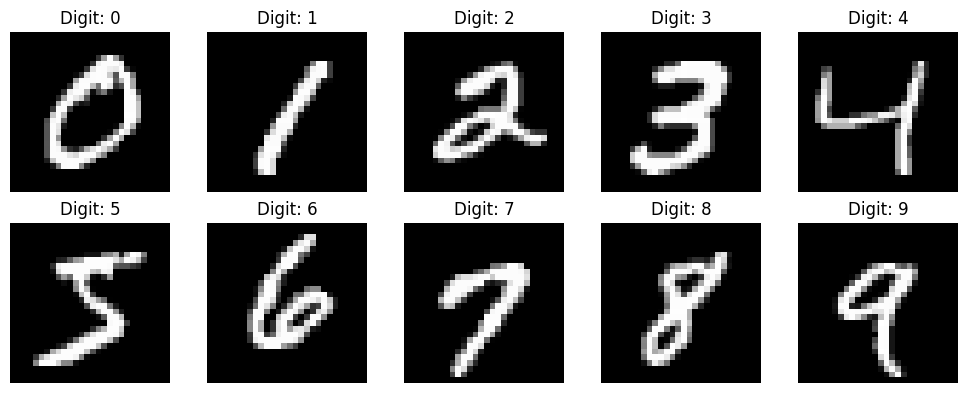

In [ ]:
csv_file = "/content/mnist_dataset.csv"

X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file )

In [ ]:
# Assert that X and y have matching lengths
assert len(X_train) == len(y_train), f"Error: X and y have different lengths! X={len(X_train)}, y={
len(y_train)}"
print("Move forward: Dimension of Feture Matrix X and label vector y matched.")

Move forward: Dimension of Feture Matrix X and label vector y matched.


Iteration 0: Cost = 1.8344
Iteration 20: Cost = 0.5929
Iteration 40: Cost = 0.4843
Iteration 60: Cost = 0.4380
Iteration 80: Cost = 0.4109


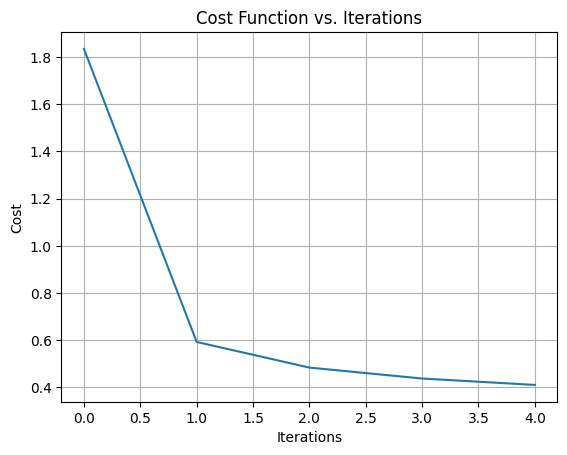

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# Check if y_train is one-hot encoded
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False) # Use sparse_output=False for newer versions of sklearn
    y_train = encoder.fit_transform(y_train.reshape(-1, 1)) # One-hot encode labels
    y_test = encoder.transform(y_test.reshape(-1, 1)) # One-hot encode test labels
# Now y_train is one-hot encoded, and we can proceed to use it
d = X_train.shape[1] # Number of features (columns in X_train)
c = y_train.shape[1] # Number of classes (columns in y_train after one-hot encoding)
# Initialize weights with small random values and biases with zeros
W = np.random.randn(d, c) * 0.01 # Small random weights initialized
b = np.zeros(c) # Bias initialized to 0
# Set hyperparameters for gradient descent
alpha = 0.5 # Learning rate
n_iter = 100 # Number of iterations to run gradient descent
# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter,show_cost=True)
# Plot the cost history to visualize the convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

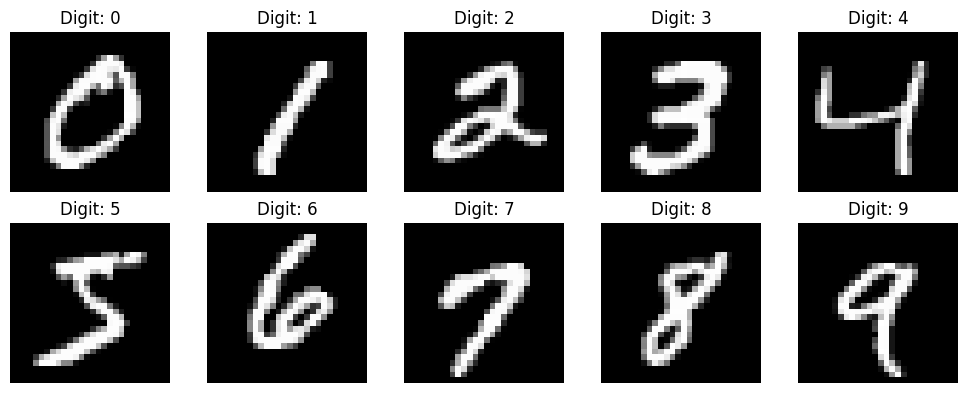


Confusion Matrix:
[[1124    0    6    3    4   10   11    2   13    2]
 [   0 1268    6   10    1    7    2    4   23    1]
 [   4   19 1013   14   22    1   29   27   34   11]
 [  10    5   34 1039    2   57   11    8   32   21]
 [   1    7    8    1 1077    2   12    3    6   59]
 [  25   22   12   46   17  899   11    7   50   15]
 [   9    4   11    1   10   19 1110    2   11    0]
 [   8   30   23    5   16    3    0 1175   10   29]
 [   8   30   13   40   10   38   13    8  987   13]
 [  10    8   12   17   45    9    0   42    8 1043]]
Precision: 0.89
Recall: 0.89
F1-Score: 0.89


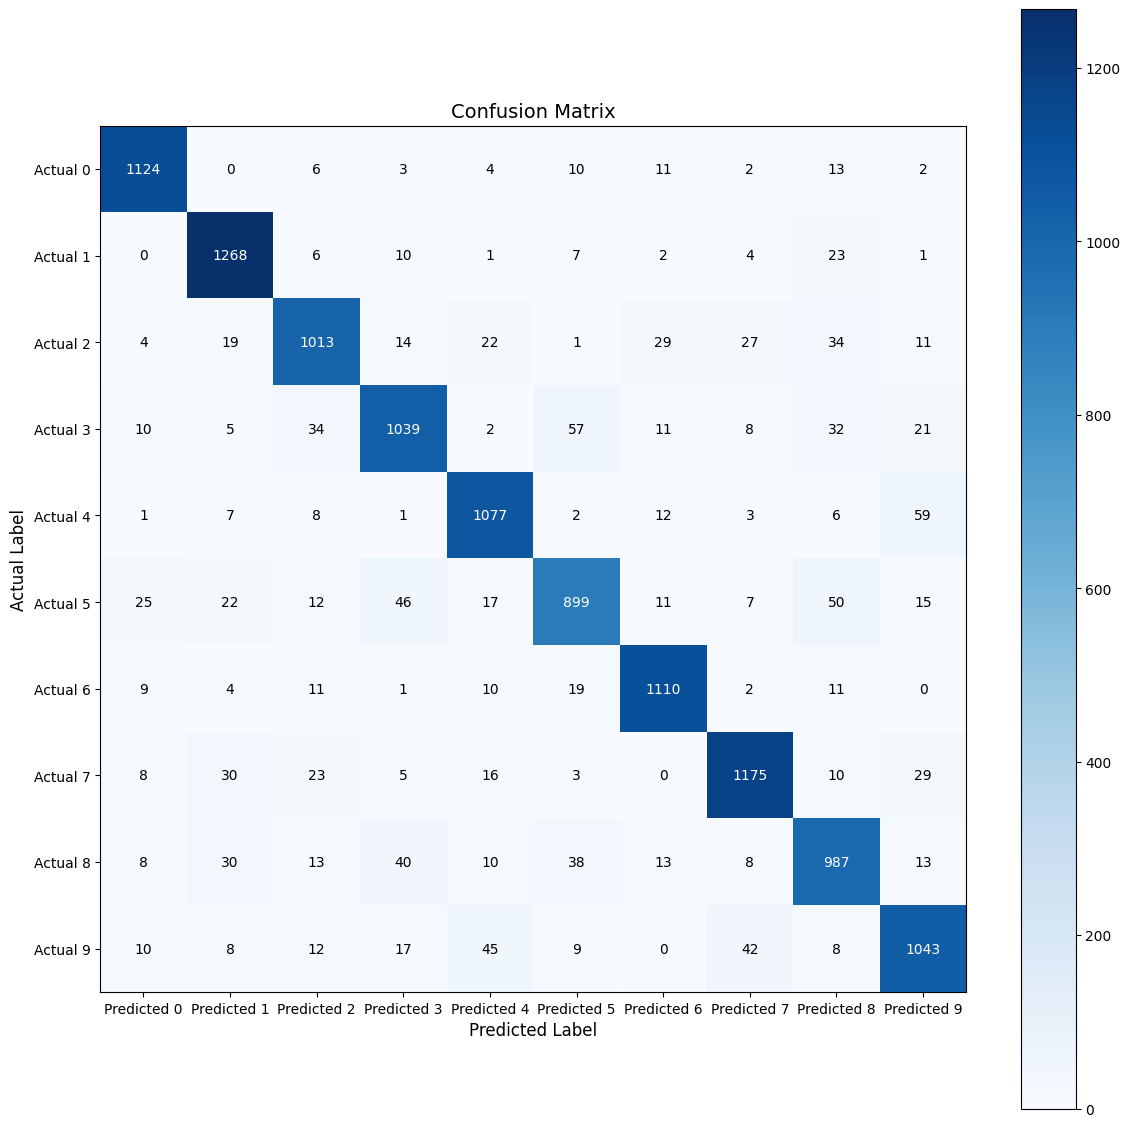

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return cm, precision, recall, f1

csv_file = "/content/mnist_dataset.csv"
_, X_test, _, y_test = load_and_prepare_mnist(csv_file ) # Re-load X_test and y_test from MNIST

# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
# Evaluate accuracy
y_test_labels = y_test # True labels are already in numeric form after loading from csv
# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)
# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
# Visualizing the Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues') # Use a color map for better visualization
# Dynamic number of classes
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
# Add labels to each cell in the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > np.max(cm) / 2 else 'black')
# Add grid lines and axis labels
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
# Adjust layout
plt.tight_layout()
plt.colorbar(cax)
plt.show()

✓ Enhanced plot saved as 'decision_boundaries_enhanced.png'


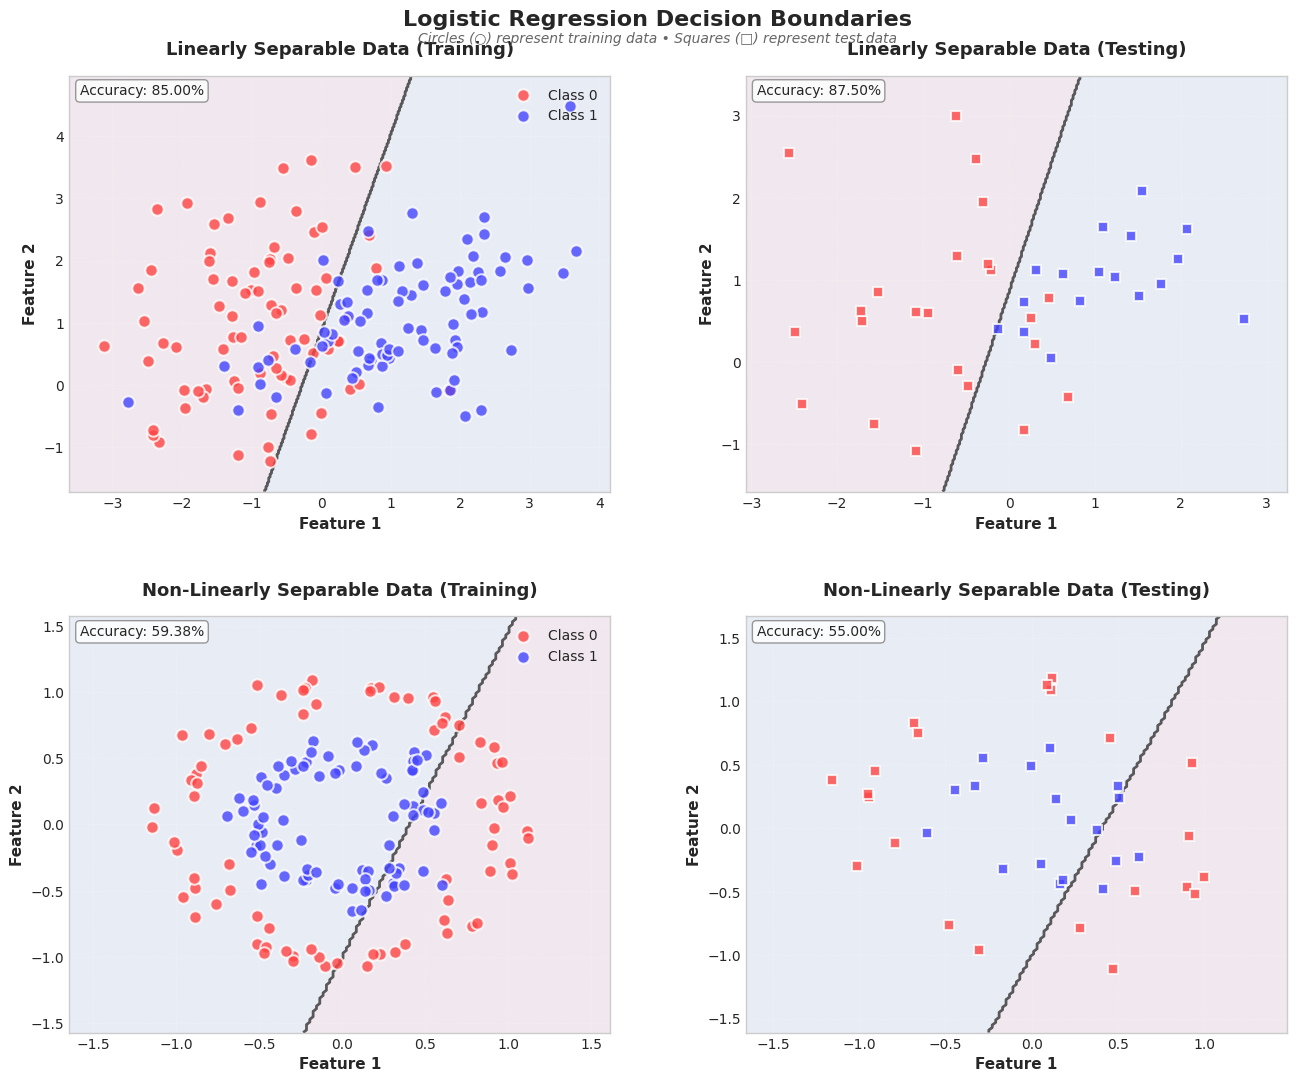

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility
np.random.seed(42)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# Define custom color schemes
bg_colors = ListedColormap(['#FFE5E5', '#E5F2FF'])  # Soft red and blue backgrounds
point_colors = ['#FF4444', '#4444FF']  # Vibrant red and blue for points

def plot_decision_boundary(ax, model, X, y, title, dataset_type='train'):
    """
    Plot decision boundary with enhanced styling

    Parameters:
    -----------
    ax : matplotlib axis
    model : trained model
    X : features
    y : labels
    title : plot title
    dataset_type : 'train' or 'test' to adjust styling
    """
    h = 0.02  # step size in the mesh

    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary background
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=bg_colors, levels=1)

    # Add decision boundary line
    ax.contour(xx, yy, Z, colors='#333333', linewidths=2, levels=[0.5], alpha=0.8)

    # Plot data points
    for i, color in enumerate(point_colors):
        idx = y == i
        marker = 'o' if dataset_type == 'train' else 's'
        size = 80 if dataset_type == 'train' else 60
        ax.scatter(X[idx, 0], X[idx, 1], c=color, label=f'Class {i}',
                  edgecolors='white', linewidth=1.5, s=size,
                  marker=marker, alpha=0.8, zorder=3)

    # Calculate accuracy
    accuracy = model.score(X, y)

    # Styling
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Feature 1', fontsize=11, fontweight='semibold')
    ax.set_ylabel('Feature 2', fontsize=11, fontweight='semibold')

    # Add accuracy annotation
    ax.text(0.02, 0.98, f'Accuracy: {accuracy:.2%}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

    # Add legend only to first plot
    if dataset_type == 'train' and 'Linearly' in title:
        ax.legend(loc='upper right', framealpha=0.9, edgecolor='gray')

    # Grid styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    # Spine styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1)

# Create figure with better spacing
fig = plt.figure(figsize=(14, 11))
fig.suptitle('Logistic Regression Decision Boundaries',
             fontsize=16, fontweight='bold', y=0.98)

# Add subtitle
fig.text(0.5, 0.95,
         'Circles (○) represent training data • Squares (□) represent test data',
         ha='center', fontsize=10, style='italic', color='#666666')

# Create subplots with custom spacing
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25,
                       top=0.92, bottom=0.05, left=0.08, right=0.95)

axes = []
for i in range(2):
    for j in range(2):
        axes.append(fig.add_subplot(gs[i, j]))

# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(axes[0], logistic_model_linear_separable,
                      X_train_linear, y_train_linear,
                      'Linearly Separable Data (Training)', 'train')

# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(axes[1], logistic_model_linear_separable,
                      X_test_linear, y_test_linear,
                      'Linearly Separable Data (Testing)', 'test')

# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(axes[2], logistic_model_non_linear_separable,
                      X_train_non_linear, y_train_non_linear,
                      'Non-Linearly Separable Data (Training)', 'train')

# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(axes[3], logistic_model_non_linear_separable,
                      X_test_non_linear, y_test_non_linear,
                      'Non-Linearly Separable Data (Testing)', 'test')

# Save with high quality
plt.savefig('decision_boundaries_enhanced.png',
            dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Enhanced plot saved as 'decision_boundaries_enhanced.png'")

plt.show()

Question - 1:
Is extracting pixel values sufficient for effective feature extraction? Why or why not?
Extracting pixel values alone is not sufficient for effective feature extraction because it fails to capture important patterns such as edges, shapes, and textures within the data. Additionally, raw pixel data is high-dimensional, which makes the learning process more complex and computationally expensive. It is also highly sensitive to noise and small variations in the input. Therefore, using more advanced feature extraction methods, such as features learned through Convolutional Neural Networks (CNNs), significantly improves model performance.

Question - 2: Provide an interpretation of the output based on your understanding.
In terms of output interpretation, logistic regression performs well when dealing with linearly separable data, as it can create a clear straight decision boundary that results in high accuracy. However, for non-linear data distributions, such as circular patterns, logistic regression struggles because it can only learn linear decision boundaries. As a result, it fails to properly separate the classes, leading to poor performance.

Question - 3: Describe any challenges you faced while implementing the code above.
There are several challenges encountered during implementation. These include handling matrix shape mismatches between inputs, weights, and labels, as well as understanding and correctly applying one-hot encoding. Numerical stability is another key issue, particularly avoiding problems like computing the logarithm of zero. Additionally, calculating gradients correctly can be difficult and is a common source of errors. Finally, effectively visualizing decision boundaries can also be challenging but is important for understanding model behavior.